# Read in data

In [ ]:
import pandas as pd
import numpy as np
from itertools import product, combinations
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pingouin import ttest
from pylatexenc.latexencode import unicode_to_latex as text2latex
from scipy import stats
from statsmodels.regression.mixed_linear_model import MixedLM


sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
import random

random.seed(42)
np.random.seed(42)

mypal = make_aesthetic()


def make_bold(x):
	"""
	This function is used to make part of the title bold like as a subtitle.
	Basically, it's using latex to render a (sub)string bold in matplot.
	But make_aesthetic() should handle using Arial for math font,
	so it won't look weird.
	>>> full_title = f"{make_bold("Regression Coefficients of Estimated Prevalence From Multiverse")}\n(Baseline is raw data with no weighting and no dropping)"

	"""
	#
	words = x.split()
	words = ' \\ '.join([w for w in words])  # Escape backslash properly
	bold_str = f"$\\bf{{{words}}}$"  # Correctly format the f-string
	return bold_str

def did_use(x):
    if "never" in x.lower():
        return 0
    else:
        return 1

def short_domain(x):
    if "convention" in x.lower():
        return "conventional"
    elif "moral" in x.lower():
        return "moral"
    elif "personal" in x.lower():
        return "personal"
    else:
        return "other"


def make_df():
    df = pd.read_csv("../data/qualtrics_experiments/desc_norms_interface [typing]_August 23, 2025_20.20.csv")
    # print(sorted(df.columns))
    df = df.iloc[2:]
    df = df.query("DistributionChannel=='anonymous'") # this will remove reponses from using preview link

    data_pts = []
    for i, row in df.iterrows():
        # non_loop_merge_vars
        base_pt = {
            "pid": row['ResponseId'],
            "progress": row['Progress'],
            "duration": float(row['Duration (in seconds)'])/60,
            "finished": row['Finished'],
            "feedback": row['feedback'],
            "llm_usage": row['dv_llm_usage'],
            "usage_convention": row['dv_usage_convention'],
            "usage_moral": row['dv_usage_moral'],
            "usage_personal": row['dv_usage_personal'],
            "llm_usage_binary": did_use(row['dv_llm_usage']),
            "usage_convention_binary": did_use(row['dv_usage_convention']),
            "usage_moral_binary": did_use(row['dv_usage_moral']),
            "usage_personal_binary": did_use(row['dv_usage_personal']),
        }

        # loop and merge columns:
        for i in range(1, 60):
            pre = float(row.get(f'{i}_lm_pre_11'))
            post =float( row.get(f'{i}_lm_post_11'))
            qual = row.get(f'{i}_lm_qual')
            if pd.notnull(pre) and pd.notnull(post):
                data_pt = base_pt.copy()
                data_pt['idx'] = i
                data_pt['pre'] = pre
                data_pt['post'] = post
                data_pt['qual'] = qual
                data_pts.append(data_pt)


    # We get a long dataframe with one row per trial per person
    df = pd.DataFrame(data_pts)


    # Merge in metadata
    #############################################
    #############################################
    meta_df = pd.read_csv("../data/clean/ai_rot_stimuli_new_prompt.csv")
    df = df.merge(meta_df, on='idx', how='left')
    #############################################
    #############################################

    # Clean and process
    #############################################
    #############################################

    # Distance stuff
    df['pre_distance'] = np.abs(df['pre'] - df['rating'])
    df['post_distance'] = np.abs(df['post'] - df['rating'])
    df['change_distance'] = df['pre_distance'] - df['post_distance']
    df['did_change_distance'] = df['change_distance'].apply(lambda x: 1 if x > 0 else 0)
    df['did_change'] = 1 * ((df['pre_distance'] - df['post_distance']) != 0)

    # Domain cleaning
    df['domain'] = df['domain'].map(short_domain)

    # Duration bucketing
    durations = df.drop_duplicates(subset=['pid'])['duration'].to_list()
    mean_duration = np.mean(durations)
    sd_duration = np.std(durations)
    low_threshold = mean_duration - 2*sd_duration
    df['low_duration'] = (df['duration'] < low_threshold)
    print("Number of low duration people")
    print(df['low_duration'].value_counts())


    # Usage cleaning
    usage_map = {
       "No - never used": 0,
       "Yes - less often than several times a week": 1,
       "Yes - several times a week": 2,
       "Yes - about once a day": 3,
       "Yes - several times a day": 4,
        "Yes - almost constantly": 5
    }
    for var in ['usage_personal', 'usage_moral', 'usage_convention']:
        df[f"{var}_int"] = df[var].map(usage_map)
    df['usage_sum'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].sum(axis=1)

    df.to_csv("../data/qualtrics_experiments/desc_norms_init_norm_pilot_long.csv", index=False)

    return df
    #############################################
    #############################################

df = make_df()

# Basic data quality checks

In [ ]:
from src.helpers import array_stats
from scipy.stats import ttest_ind, mannwhitneyu

print("Durations")
durations =  array_stats(df.drop_duplicates(subset=['pid'])['duration'].values, include_ci=True)
sns.regplot(data=df, x='duration', y='change_distance', x_bins=5)



 # Descriptives of change

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from src.helpers import array_stats

mypal = make_aesthetic(font_scale=1.2)
effect_size = df['pre_distance'] - df['post_distance']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#################################################################
# Pre_distance and post_distance as overlaid histograms
#################################################################
ax1 = axes[0]
ax1.hist(df['pre_distance'], bins=30, alpha=1, label='Pre Exposure Distance',  edgecolor='black')
ax1.hist(df['post_distance'], bins=30, alpha=1, label='Post Exposure Distance', edgecolor='black')
ax1.set_xlabel('Distance from AI Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Pre vs Post Distance from AI')
ax1.legend()
ax1.grid(True, alpha=0.3)

#################################################################
# Distribution of effect sizes
#################################################################
ax2 = axes[1]
closer_to_ai = effect_size[effect_size > 0]
further_from_ai = effect_size[effect_size < 0]

ax2.hist(closer_to_ai, bins=30, alpha=1, label=f'Closer to AI (n={len(closer_to_ai)})',
color=mypal[1], edgecolor='black')
ax2.hist(further_from_ai, bins=30, alpha=1, label=f'Further from AI (n={len(further_from_ai)})',
         color=mypal[0], edgecolor='black')
ax2.axvline(0, color='gray', linestyle='--', alpha=0.8, linewidth=2)
ax2.axvline(effect_size.mean(), color='black', linestyle='--', alpha=0.8, linewidth=2,
            label=f'Mean: {effect_size.mean():.3f}')

ax2.set_xlabel('Effect Size (Pre Distance - Post Distance)')
ax2.set_ylabel('Frequency')
ax2.set_title('Effect Size Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)


plt.show()


######################################
# Statistics
######################################

def get_mixed_model_estimate(data):
    formula = 'change_distance ~ 1'
    data['dummy'] = 1
    model = MixedLM.from_formula(formula, data=data,
                             groups='dummy',
                             vc_formula={'id1': "0 + C(pid)",
                                         'id2': "0 + C(rot)"}
                                         ).fit()
    mixed_model_estimate = model.fe_params['Intercept']
    ci = model.conf_int()
    mixed_model_low, mixed_model_high = ci.loc['Intercept']
    return mixed_model_estimate, mixed_model_low, mixed_model_high

def bootstrap_dz(data, n_bootstraps=10000):
    boot_dz = []
    n = len(data)
    for i in range(n_bootstraps):
        sample = np.random.choice(data, size=n, replace=True)
        mean_diff = np.mean(sample)
        sd_diff = np.std(sample, ddof=1)
        if sd_diff != 0:
            boot_dz.append(mean_diff / sd_diff)
    return np.percentile(boot_dz, [2.5, 97.5])

def compute_change_metrics(pre, post):
    effect_size = pre - post
    mean_diff = effect_size.mean()
    sd_diff = effect_size.std()
    mixed_model_estimate, mixed_model_low, mixed_model_high = get_mixed_model_estimate(df)
    cohens_dz = mean_diff / sd_diff
    ci_lower, ci_upper = bootstrap_dz(effect_size)
    moved_closer = effect_size > 0
    moved_further = effect_size < 0
    no_change = effect_size == 0
    wilcox_w = stats.wilcoxon(pre, post)

    # Calculate percentages
    n = len(effect_size)
    percent_closer = moved_closer.sum() / n
    percent_further = moved_further.sum() / n
    percent_no_change = no_change.sum() / n

    data =  {
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "cohens_dz": cohens_dz,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "moved_closer": moved_closer,
        "moved_further": moved_further,
        "no_change": no_change,
        "wilcox_w": wilcox_w.statistic,
        "wilcox_p": wilcox_w.pvalue,
        "mixed_model_estimate": mixed_model_estimate,
        "mixed_model_low": mixed_model_low,
        "mixed_model_high": mixed_model_high,
    }
    stats_str = f"""
    The mean effect (reduction in distance to AI rating) was {mean_diff:.2f} (SD = {sd_diff:.2f}) on an agreement scale of 0-100, with a Cohen's dz of {cohens_dz:.2f} (95% CI [{ci_lower:.2f}, {ci_upper:.2f}]) and Wilcoxon signed-rank test of W = {wilcox_w.statistic}, p = {wilcox_w.pvalue:.1e}. In {percent_closer*100:.0f}% of cases, participants moved closer to the AI rating, in {percent_further*100:.0f}% of cases they moved further away, and in {percent_no_change*100:.0f}% of cases there was no change. A mixed-effects model with crossed random intercepts for participants and items produced a very similar estimate to the raw estimate (beta = {mixed_model_estimate:.2f}, (95% CI [{mixed_model_low:.2f}, {mixed_model_high:.2f}]) of reduction in distance to AI rating."""
    print(stats_str)
    return data

metrics = compute_change_metrics(df['pre_distance'], df['post_distance'])



# By factors

## Descriptive plots

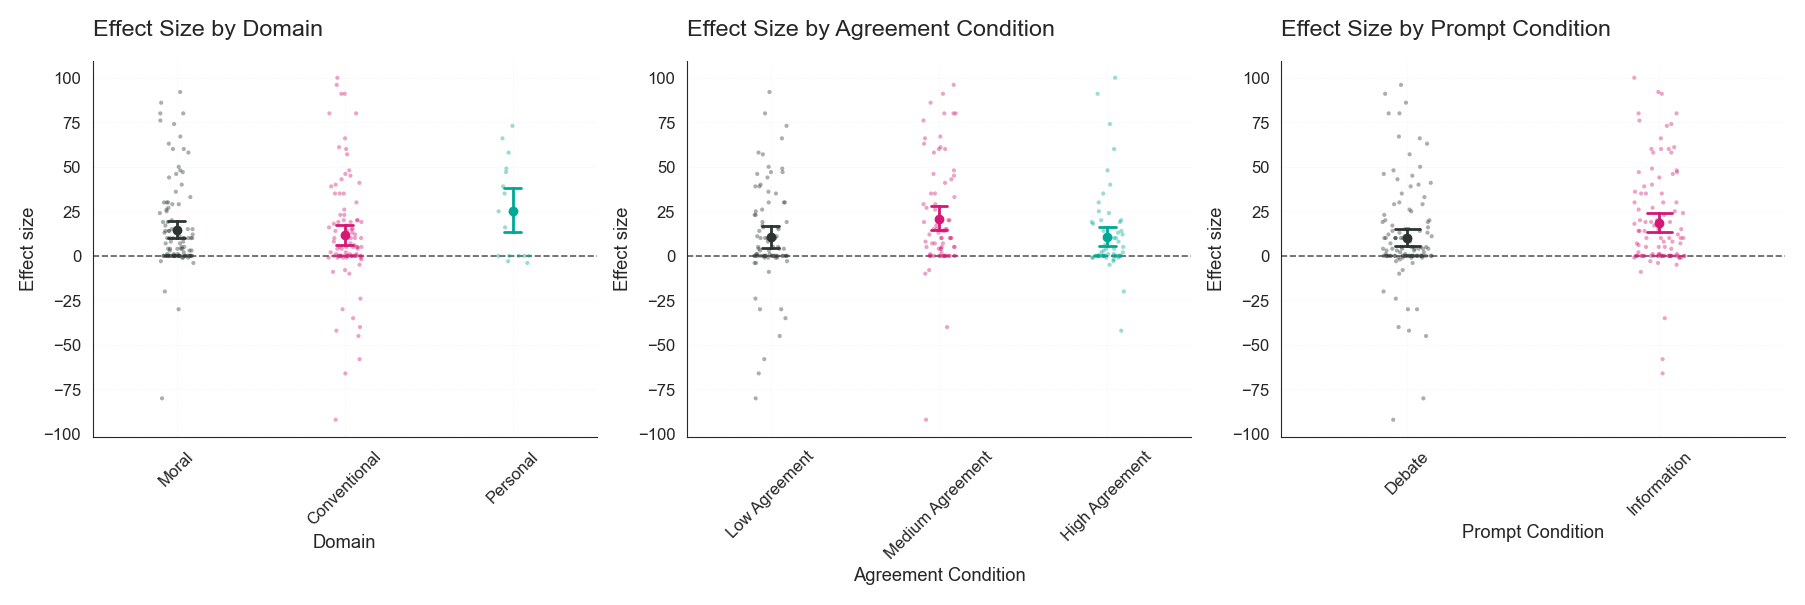

In [209]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


#############################################
# Grid plot by factors
#############################################
mypal = make_aesthetic(font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mypal = make_aesthetic(font_scale=1.2)
factors = ['domain', 'agreement_condition', 'prompt_condition']
factor_titles = ['Domain', 'Agreement Condition', 'Prompt Condition']

for i, (factor, title) in enumerate(zip(factors, factor_titles)):
    ax = axes[i]

    sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
                 capsize=0.1, errwidth=2, ax=ax)

    sns.stripplot(x=factor, y='change_distance', data=df, palette=mypal,
                 alpha=0.4, size=3, ax=ax)

    ax.axhline(y=0, color='k', linestyle='--', alpha=0.7)

    labels = [label.get_text().replace('_', ' ').title() for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45)

    ax.set_title(f"Effect Size by {title}")
    ax.set_ylabel("Effect size")
    ax.set_xlabel(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#############################################
#############################################

## Mixed effects model

                                            Mixed Linear Model Regression Results
Model:                                   MixedLM                      Dependent Variable:                      change_distance
No. Observations:                        226                          Method:                                  REML           
No. Groups:                              1                            Scale:                                   681.9786       
Min. group size:                         226                          Log-Likelihood:                          -1050.2178     
Max. group size:                         226                          Converged:                               Yes            
Mean group size:                         226.0                                                                                
------------------------------------------------------------------------------------------------------------------------------
                             

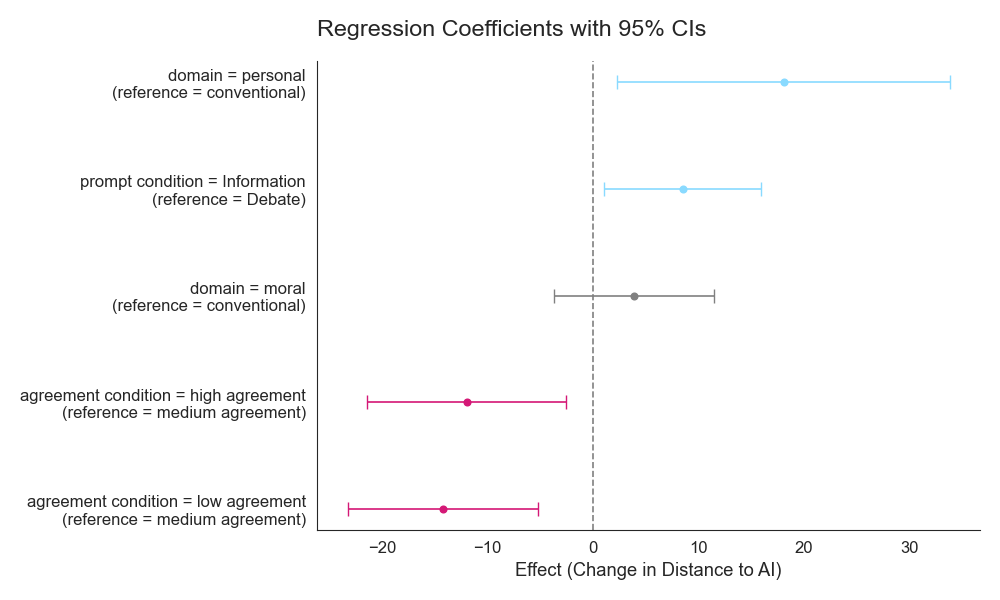

In [210]:
# Baseline model --- crossed random effects for person and stimulus
##########################################################################################
##########################################################################################

# https://github.com/statsmodels/statsmodels/issues/9279
formula = 'change_distance ~ C(domain, Treatment(reference="conventional")) + C(agreement_condition, Treatment(reference="medium_agreement")) + C(prompt_condition, Treatment(reference="Debate"))'
df['dummy'] = 1
model = MixedLM.from_formula(formula, data=df,
                             groups='dummy',
                             vc_formula={'id1': "0 + C(pid)",
                                         'id2': "0 + C(rot)"}
                                         )

result = model.fit()
print(result.summary())
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
handler = StatsmodelsHandler(result)
handler.to_latex()
handler.plot(clean_var_name=clean_var_name_from_formula)
plt.xlabel("Effect (Change in Distance to AI)")
plt.ylabel("")
plt.title("Regression Coefficients with 95% CIs")
plt.show()

# Where are these changes coming from?

## Transition matrices

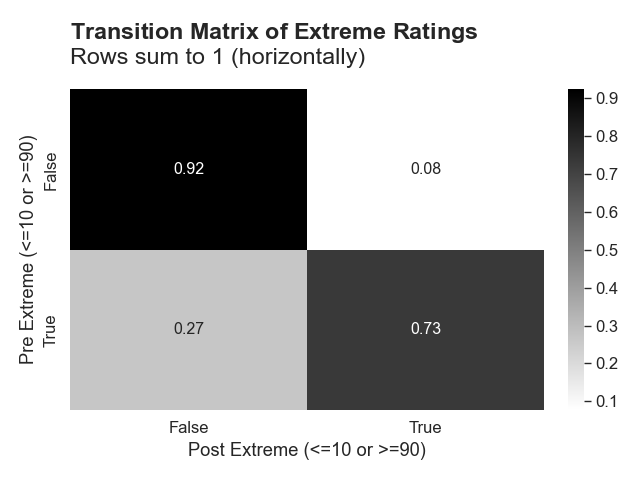

Text(0.0, 1.0, '$\\bf{Transition \\ Matrix \\ of \\ Rating \\ Buckets}$\nRows sum to 1 (horizontally)')

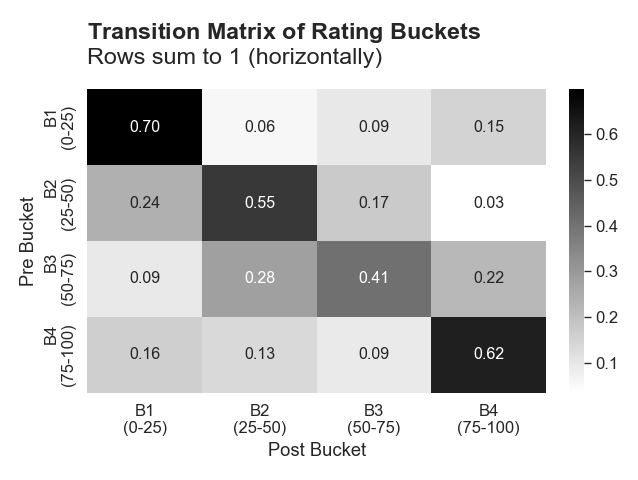

In [211]:
from src.helpers import make_aesthetic
mypal = make_aesthetic(font_scale=1.2)

def get_bucket_number(x):
    x = x.split("\n")[0][1:]
    return x

def is_extreme(x):
    return x < 10 or x > 90

def bucket_label(x, n_bins):
    bins = np.linspace(0, 100, n_bins + 1)
    labels = [f"B{i+1}\n({int(bins[i])}-{int(bins[i+1])})" for i in range(n_bins)]
    return pd.cut([x], bins=bins, labels=labels, include_lowest=True, ordered=True)[0]

df['pre_extreme'] = df['pre'].apply(is_extreme)
df['post_extreme'] = df['post'].apply(is_extreme)

####################################
# Transition matrix of extremes
####################################
sns.heatmap(
    pd.crosstab(df['pre_extreme'], df['post_extreme'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Extreme (<=10 or >=90)")
plt.ylabel("Pre Extreme (<=10 or >=90)")
plt.title(f"{make_bold("Transition Matrix of Extreme Ratings")}\nRows sum to 1 (horizontally)")
plt.show()


####################################
# Transition matrix of pre/post buckets
####################################
N_BINS=4
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
sns.heatmap(
    pd.crosstab(df['pre_bucket'], df['post_bucket'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Bucket")
plt.ylabel("Pre Bucket")
plt.title(f"{make_bold("Transition Matrix of Rating Buckets")}\nRows sum to 1 (horizontally)")
####################################

In [212]:
pd.crosstab(df['pre_bucket'], df['post_bucket'])

post_bucket,B1\n(0-25),B2\n(25-50),B3\n(50-75),B4\n(75-100)
pre_bucket,,,,
B1\n(0-25),37,3,5,8
B2\n(25-50),7,16,5,1
B3\n(50-75),3,9,13,7
B4\n(75-100),18,15,10,69


## Effect size by (pre-exposure, AI rating) bins

Text(0, 0.5, 'Effect')

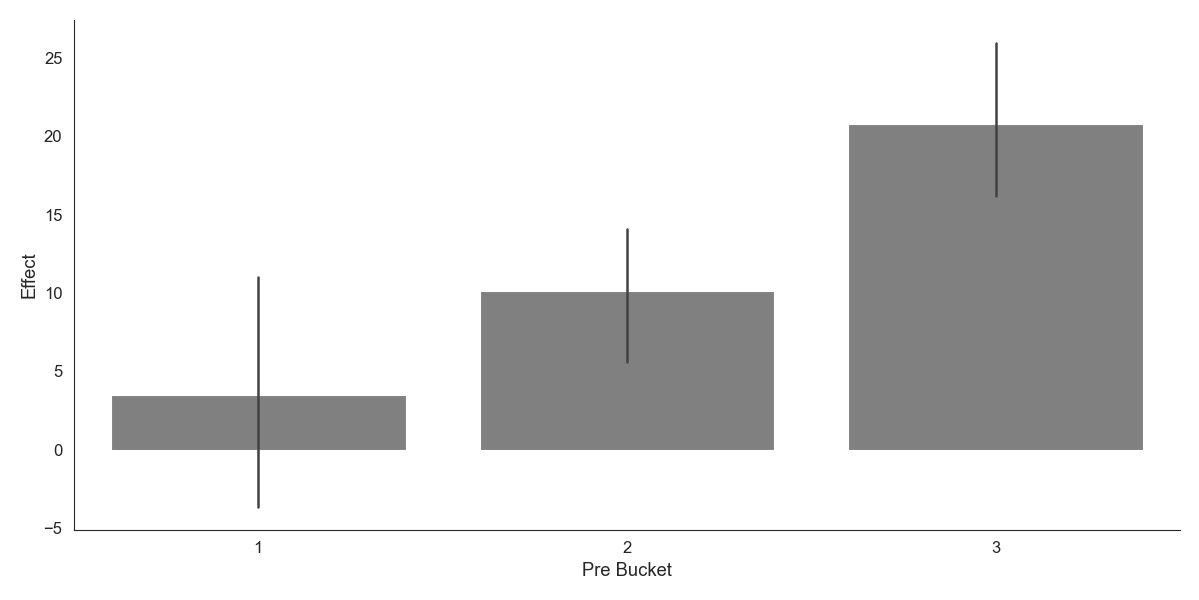

In [213]:
def get_bucket_number(x):
    x = x.split("\n")[0][1:]
    return x

N_BINS=3
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
df['pre_bucket_int'] = df['pre_bucket'].apply(get_bucket_number).astype(int)
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='pre_bucket_int', y='change_distance', color='gray')
plt.xlabel("Pre Bucket")
plt.ylabel("Effect")




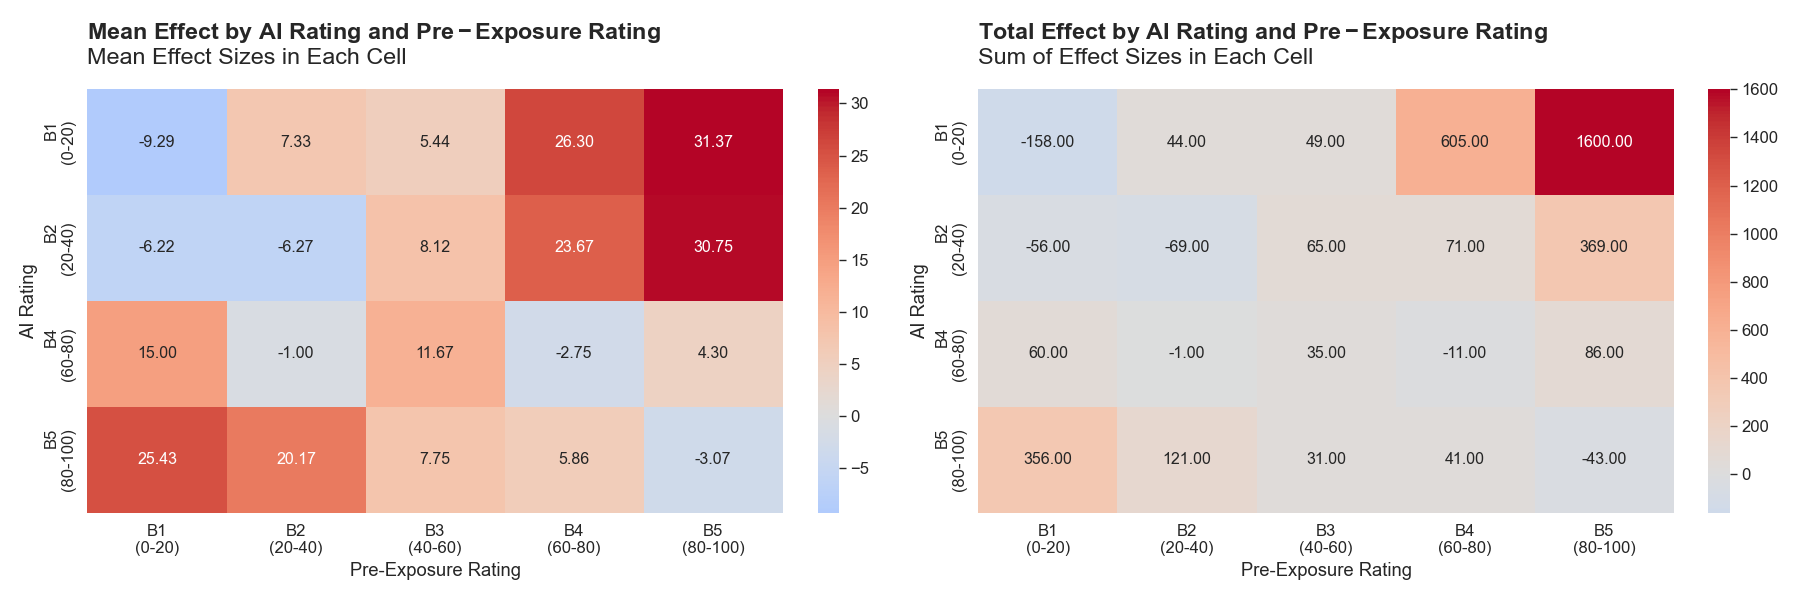

In [214]:
mypal = make_aesthetic(font_scale=1.2)
N_BINS = 5

df['rating_bucket'] = df['rating'].apply(bucket_label, n_bins=N_BINS)
df['rating_bucket_int'] = df['rating_bucket'].apply(get_bucket_number).astype(int)

df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['pre_bucket_int'] = df['pre_bucket'].apply(get_bucket_number).astype(int)

# Get the sorted bucket categories
rating_order = [x for _, x in sorted(zip(df['rating_bucket_int'], df['rating_bucket'].astype(str).unique()), key=lambda t: int(get_bucket_number(t[1])))]
pre_order = [x for _, x in sorted(zip(df['pre_bucket_int'], df['pre_bucket'].astype(str).unique()), key=lambda t: int(get_bucket_number(t[1])))]



fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mean of effects
heatmap_mean = df.pivot_table(index='rating_bucket', columns='pre_bucket', values='change_distance', aggfunc='mean')
heatmap_mean = heatmap_mean.reindex(index=rating_order, columns=pre_order)
sns.heatmap(heatmap_mean, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_xlabel("Pre-Exposure Rating")
axes[0].set_ylabel("AI Rating")
axes[0].set_title(f"{make_bold('Mean Effect by AI Rating and Pre-Exposure Rating')}\nMean Effect Sizes in Each Cell")

# Sum of effects
heatmap_sum = df.pivot_table(index='rating_bucket', columns='pre_bucket', values='change_distance', aggfunc='sum')
heatmap_sum = heatmap_sum.reindex(index=rating_order, columns=pre_order)
sns.heatmap(heatmap_sum, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_xlabel("Pre-Exposure Rating")
axes[1].set_ylabel("AI Rating")
axes[1].set_title(f"{make_bold('Total Effect by AI Rating and Pre-Exposure Rating')}\nSum of Effect Sizes in Each Cell")


plt.show()

## Denormalization vs Normalization

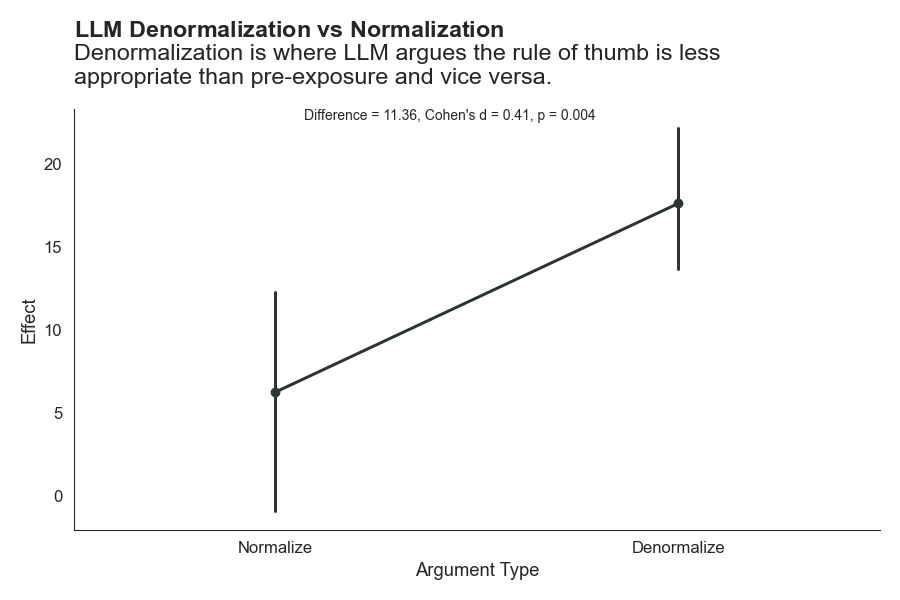

In [215]:
from scipy.stats import permutation_test

def cohens_d(x, y):
   nx, ny = len(x), len(y)
   pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
   return (np.mean(x) - np.mean(y)) / pooled_std

def statistic(x, y):
   return np.mean(x) - np.mean(y)

df['convince_type'] = np.where(df['rating'] < df['pre'], "Denormalize", "Normalize")
denorm = df[df['convince_type'] == 'Denormalize']['change_distance']
norm = df[df['convince_type'] == 'Normalize']['change_distance']
cohens_d = cohens_d(denorm, norm)
res = permutation_test((denorm, norm), statistic, n_resamples=10000, alternative='two-sided', random_state=42)
plt.figure(figsize=(9, 6))
sns.pointplot(data=df, x='convince_type', y='change_distance')
plt.ylabel("Effect")
plt.xlabel("Argument Type")
plt.title(f"{make_bold('LLM Denormalization vs Normalization')}\nDenormalization is where LLM argues the rule of thumb is less\nappropriate than pre-exposure and vice versa.")
stats_dz_str = f"Difference = {res.statistic:.2f}, Cohen's d = {cohens_d:.2f}, p = {res.pvalue:.3f}"
plt.figtext(0.5, 0.8, stats_dz_str, ha="center", fontsize=10)
plt.show()

# Individual differences

In [ ]:
pid_cols = [c for c in df.columns if "usage" in c] + ["pid", "feedback"]

byp = (
    df.groupby(pid_cols)['change_distance']
      .agg(mean=np.mean, sd=np.std)
      .reset_index()
)
sns.scatterplot(data=df.sort_values(by=['change_distance']), y='pid', x='change_distance', hue='change_distance')


# How frequently do ppl use LLMs?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint

from src.helpers import make_aesthetic


# Get color palette
mypal = make_aesthetic(font_scale=1.2)


# Create the any usage indicator
##################################################

byp['any_usage'] = ((byp['usage_personal_binary'] == 1) |
                   (byp['usage_moral_binary'] == 1) |
                   (byp['usage_convention_binary'] == 1)).astype(int)


# Get wilson CIs
##################################################
usage_vars = ['usage_personal_binary', 'usage_moral_binary', 'usage_convention_binary', 'any_usage']
labels = ['Personal', 'Moral', 'Conventional', 'Any SSL Usage']
summary_data = []
for var, label in zip(usage_vars, labels):
    count = byp[var].sum()
    total = len(byp)
    prop = count / total
    ci_low, ci_high = proportion_confint(count, total, method='wilson')

    summary_data.append({
        'usage_type': label,
        'proportion': prop,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'count': count,
        'total': total
    })

usage_df = pd.DataFrame(summary_data)
print(usage_df)


# Plot
##################################################
plt.figure(figsize=(10, 6))
bars = plt.bar(usage_df['usage_type'], usage_df['proportion'],
               color=mypal[:len(usage_df)], alpha=0.7)
errors = [usage_df['proportion'] - usage_df['ci_low'],
          usage_df['ci_high'] - usage_df['proportion']]
plt.errorbar(usage_df['usage_type'], usage_df['proportion'], yerr=errors,
             fmt='none', color='black', capsize=5)
for i, row in usage_df.iterrows():
    plt.text(i, row['ci_high'] + 0.02, f"{row['proportion']:.2f}\n[{row['ci_low']:.2f}, {row['ci_high']:.2f}]",
             ha='center', va='bottom', fontweight='bold')

plt.ylabel('Proportion Ever Used')
plt.axhline(y=0.66, color='red', linestyle='--', alpha=0.7, label="0.66 is current estimate from meta-analysis")
plt.legend(loc='lower right')
plt.title('Synthetic Social Learning Usage by Participants (95% Wilson CI)')
plt.ylim(0, 1)
plt.show()

In [ ]:
usage_map = {
   "No - never used": 0,
   "Yes - less often than several times a week": 1,
   "Yes - several times a week": 2,
   "Yes - about once a day": 3,
   "Yes - several times a day": 4,
    "Yes - almost constantly": 5
}

df['any_usage'] = ((df['usage_personal_binary'] == 1) |
                   (df['usage_moral_binary'] == 1) |
                   (df['usage_convention_binary'] == 1)).astype(int)

for var in ['usage_personal', 'usage_moral', 'usage_convention']:
    df[f"{var}_int"] = df[var].map(usage_map)
    sns.barplot(data=df, x=f"{var}_int", y='change_distance')
    plt.show()
df['usage_sum'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].sum(axis=1)

df['usage_mean'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].mean(axis=1)

sns.barplot(data=df, x='usage_sum', y='change_distance')
plt.xlabel("Individual-Level Sum of Synthetic Social Knowledge Usage")
plt.ylabel("Average Effect")
plt.title("Avg Effect (Pre Distance minus Post Distance)\nby Synthetic Social Knowledge Usage")
plt.show()

# Qual

## Overall feedback

In [ ]:
for idx, row in byp.dropna(subset=['feedback']).sort_values(by=['mean'], ascending=False).iterrows():
    print(f"PID: {row['pid']}")
    print(f"Mean Change: {row['mean']:.2f}")
    print(f"Feedback: {row['feedback']}")
    print("====")


## Trial level

In [ ]:
from src.sbert_clusterer import SBERTClusterer
qdf = df.dropna(subset=['qual'])

qdf = df.dropna(subset=['qual']).copy()
qdf['change_distance_q'] = pd.qcut(qdf['change_distance'], 3).cat.codes + 1


clusterer = SBERTClusterer()
results = {}  # store results for each quartile bin

for q in sorted(qdf['change_distance_q'].unique()):
    print("="*80)
    print(f"Clustering for qcut bin: {q}")
    print("="*80)

    texts = qdf.loc[qdf['change_distance_q'] == q, 'qual'].tolist()

    if len(texts) < 2:
        print(f"Not enough texts for clustering in bin {q}. Skipping.")
        continue

    best_k = clusterer.find_k(texts, k_min=2, k_max=10, plot=False)

    clustered_df = clusterer.apply_clustering(texts, k=best_k)

    results[q] = {
        "best_k": best_k,
        "clustered_df": clustered_df,
        "summary": clusterer.get_cluster_summary()
    }



# Spaghetti plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

make_aesthetic(font_scale=1.5)
fig, ax = plt.subplots(figsize=(9, 6))

# make the lines
colors = sns.color_palette("RdBu_r", 2)
dec_color, inc_color = colors[0], colors[1]
max_change = df['change_distance'].abs().max()
for i in range(len(df)):
    pre_val = df['pre_distance'].iloc[i]
    post_val = df['post_distance'].iloc[i]
    change = post_val - pre_val
    color = inc_color if change > 0 else dec_color
    ax.plot([0, 1], [pre_val, post_val],
            color=color,
            alpha=0.15 + 0.7 * (abs(change) / max_change),
            linewidth=0.7)

# Mean trajectory
mean_pre = df['pre_distance'].mean()
mean_post = df['post_distance'].mean()
ax.plot([0, 1], [mean_pre, mean_post],
        color="black", linewidth=1, label="Mean trajectory")

# Confidence intervals
ci_pre = (df['pre_distance'].mean() - 1.96*df['pre_distance'].std()/np.sqrt(len(df)),
          df['pre_distance'].mean() + 1.96*df['pre_distance'].std()/np.sqrt(len(df)))
ci_post = (df['post_distance'].mean() - 1.96*df['post_distance'].std()/np.sqrt(len(df)),
           df['post_distance'].mean() + 1.96*df['post_distance'].std()/np.sqrt(len(df)))
ax.fill_between([0, 0], ci_pre[0], ci_pre[1], color="black", alpha=1)
ax.fill_between([1, 1], ci_post[0], ci_post[1], color="black", alpha=1)


title = f"{make_bold('All Pre-Post Trajectories')}"
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre", "Post"])
ax.set_ylabel("Distance from AI Rating")
ax.set_title(title)
ax.legend(frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()


# For what things did ppl change?

In [ ]:
byr = df.groupby(by=['rot'])[['pre_distance', 'post_distance', 'change_distance', 'rating']].agg(['mean', 'std']).reset_index().dropna()
byr.columns = ['_'.join(col).strip() if col[1] else col[0] for col in byr.columns.values]
byr['snr'] = byr['change_distance_mean'] / byr['change_distance_std']

sns.histplot(byr['change_distance_std'], bins=30, kde=True)
plt.xlabel("SD of Change Distance by ROT")
plt.show()

sns.histplot(byr['snr'], bins=30, kde=True)
plt.xlabel("SNR of Change Distance by ROT")
plt.show()

In [ ]:
byr['snr'].describe()

## Double click on high SNR items (mean/sd > 1)

In [ ]:
for idx, row in byr.query("snr > 1").iterrows():
    print(f"ROT: {row['rot']}, RATING: {row['rating_mean']:.2f}, SNR: {row['snr']:.2f}, Mean Change: {row['change_distance_mean']:.2f}, SD Change: {row['change_distance_std']:.2f}")
    rot_df = df.query("rot == @row['rot']")
    for _, r in rot_df.iterrows():
        print(f"  PID: {r['pid']}, Pre: {r['pre']:.2f}, Post: {r['post']:.2f}, Change: {r['change_distance']:.2f}, Qual: {r['qual']}")
    print("===")

In [ ]:
sns.scatterplot(data=df, x='rating', y='change_distance', alpha=0.3)

# Feedback at end

In [ ]:
end_df = df.groupby(by=['pid', 'feedback'])['change_distance'].mean().reset_index()
for idx, row in end_df.dropna(subset=['feedback']).sort_values(by=['change_distance'], ascending=False).iterrows():
    print(f"PID: {row['pid']}")
    print(f"Mean Change: {row['change_distance']:.2f}")
    print(f"Feedback: {row['feedback']}")
    print("====")

# Spline stuff

In [ ]:
df

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, te
from sklearn.model_selection import train_test_split
mypal = make_aesthetic(font_scale=1.4)
df = make_df()
df['update'] = df['post'] - df['pre']
df['difference'] = df['rating'] - df['pre']


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
y_train = train_df['update'].values
y_test = test_df['update'].values


def analyze_and_find_best_model(train_df, y_train, test_df, y_test, models_to_test):
    """
    For each model configuration:
    1. Tunes the model on the TRAINING data using gridsearch (optimizing GCV).
    2. Evaluates the tuned model on the TEST data using Correlation.
    3. Returns the model with the best TEST Correlation.
    """
    best_model = None
    best_correlation = -1.0 # Initialize with the lowest possible correlation
    best_model_info = {}

    model_results = {}

    for model_config in models_to_test:
        predictor_cols = model_config['predictors']
        interaction = model_config.get('interaction', False)

        if interaction:
            model_name = f"{predictor_cols[0]} * {predictor_cols[1]} (Interaction)"
            formula = te(0, 1, n_splines=[15, 15])
        else:
            model_name = " + ".join(predictor_cols)
            formula = s(0, n_splines=15) + s(1, n_splines=15)

        print("\n" + "="*50)
        print(f"--- Testing Model: {model_name} ---")

        X_train = train_df[predictor_cols].values
        X_test = test_df[predictor_cols].values

        # Step 1: Tune model on training data. Gridsearch internally uses GCV.
        gam = LinearGAM(formula)
        gam.gridsearch(X_train, y_train, progress=False)

        # Step 2: Evaluate the tuned model on the test data with Correlation.
        predictions = gam.predict(X_test)
        correlation = np.corrcoef(y_test, predictions)[0, 1]
        model_results[model_name] = correlation
        print(f"--> TEST CORRELATION: {correlation:.4f}")

        # Step 3: Check if this model is the best so far based on TEST CORRELATION.
        if correlation > best_correlation:
            best_correlation = correlation
            best_model = gam
            best_model_info = {
                'name': model_name,
                'predictors': predictor_cols,
                'interaction': interaction,
                'correlation': correlation
            }

    print("\n" + "="*50)
    # Sort by correlation descending
    sorted_results = sorted(model_results.items(), key=lambda item: item[1], reverse=True)
    for model_name, score in sorted_results:
        print(f"Model '{model_name}': {score:.4f}")

    return best_model, best_model_info

def plot_best_model(gam, model_info):
    """Visualizes the single best performing model."""
    print("\n" + "="*50)
    print(f"--- Visualizing Best Model: {model_info['name']} ---")

    titles = model_info['predictors']
    X_train = train_df[titles].values # Use original training data for visualization range

    if model_info['interaction']:
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        XX = gam.generate_X_grid(term=0, n=50, meshgrid=True)
        Z = gam.partial_dependence(term=0, X=XX, meshgrid=True)
        ax.plot_surface(XX[0], XX[1], Z, cmap='viridis', edgecolor='none')
        ax.set_xlabel(titles[0])
        ax.set_ylabel(titles[1])
        ax.set_zlabel("Partial Effect on 'update'")
        ax.set_title(f"Interaction Surface for Best Model: {model_info['name']}", fontsize=16)
        plt.show()
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for i, ax in enumerate(axes):
            XX = gam.generate_X_grid(term=i, n=100)
            pdep, conf_intervals = gam.partial_dependence(term=i, X=XX, width=.95)
            ax.plot(XX[:, i], pdep, color='blue', lw=3)
            ax.fill_between(XX[:, i], conf_intervals[:, 0], conf_intervals[:, 1], color='skyblue', alpha=0.5)
            ax.set_title(f"Partial Dependence for '{titles[i]}'", fontsize=14)
            ax.set_xlabel(titles[i], fontsize=12)
            ax.set_ylabel("Partial Effect on 'update'", fontsize=12)
        plt.suptitle(f"Partial Dependence Plots for Best Model: {model_info['name']}", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()


# Define all models to be tested
models_to_test = [
    # Additive models
    {'predictors': ['pre', 'rating'], 'interaction': False},
    {'predictors': ['difference', 'pre'], 'interaction': False},
    {'predictors': ['difference', 'rating'], 'interaction': False},
    # Interaction models
    {'predictors': ['pre', 'rating'], 'interaction': True},
    {'predictors': ['difference', 'pre'], 'interaction': True},
    {'predictors': ['difference', 'rating'], 'interaction': True}
]

best_gam, best_model_info = analyze_and_find_best_model(train_df, y_train, test_df, y_test, models_to_test)

if best_gam:
    print("\n" + "="*50)
    print(f"--- Final Report for Best Model: '{best_model_info['name']}' ---")
    print(f"This model was selected because it had the highest correlation on unseen test data.")
    print(f"Final Test Correlation: {best_model_info['correlation']:.4f}")

    plot_best_model(best_gam, best_model_info)
    print("\n--- Best Model Summary (Trained on Training Data) ---")
    best_gam.summary()



# Experimental

Stuff around modeling updates. I am trying to see the best way to model `update`. It needs to not overfit because we are using this in a simulation.

- OLS
- Random effects models
- Random forests
- Splines

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Model Imports ---
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
from pygam import LinearGAM, s, f
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge

# --- Scikit-learn Tools ---
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Wrapper for statsmodels MixedLM
class MixedLMEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, formula, groups, vc_formula, re_formula=None):
        self.formula, self.groups = formula, groups
        self.vc_formula, self.re_formula = vc_formula, re_formula
    def fit(self, X, y=None):
        data = X.copy(); data['update'] = y
        model = MixedLM.from_formula(self.formula, data, groups=self.groups,
                                     re_formula=self.re_formula, vc_formula=self.vc_formula)
        self.model_ = model.fit(reml=True, method='lbfgs')
        return self
    def predict(self, X):
        return self.model_.predict(X)

################################
# 1. Data Preparation
################################
analysis_df = df[['pid', 'rot', 'pre', 'post', 'rating']].dropna().copy()
analysis_df['update'] = analysis_df['post'] - analysis_df['pre']
analysis_df['diff'] = analysis_df['rating'] - analysis_df['pre']
analysis_df['dummy'] = 1
analysis_df['pre_extreme'] = np.abs(analysis_df['pre'] - 50)
analysis_df['pre_sign'] = (analysis_df['pre'] > 50).astype(int)

analysis_df['ai_extremity'] = np.abs(analysis_df['rating'] - 50)
analysis_df['agreement_sign'] = (np.sign(analysis_df['pre'] - 50) == np.sign(analysis_df['rating'] - 50)).astype(int)
analysis_df['diff_squared'] = analysis_df['diff']**2
analysis_df['is_ai_more_extreme'] = (analysis_df['ai_extremity'] > analysis_df['pre_extreme']).astype(int)

for col in ['pid', 'rot']:
    if col in analysis_df.columns:
        analysis_df[f'{col}_code'] = analysis_df[col].astype('category').cat.codes

y = analysis_df['update']
X = analysis_df.drop(columns=['update'])

################################
# 2. Cross-Validation Setup
################################
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model_scores = {}

main_predictors = [
    'diff', 'pre_extreme', 'pre_sign', 'ai_extremity', "pre",
    'agreement_sign', 'diff_squared', 'is_ai_more_extreme'
]
id_predictors_code = ['pid_code', 'rot_code']
sklearn_features = main_predictors + id_predictors_code
gam_features = main_predictors + id_predictors_code
mixedlm_features = main_predictors + ['pid', 'rot']

print("Starting 5-fold cross-validation...")
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"--- Fold {fold+1}/5 ---")
    train_df, test_df = analysis_df.iloc[train_index], analysis_df.iloc[test_index]
    y_train, y_test = train_df['update'], test_df['update']

    if fold == 0:
        model_names = [
            'Full OLS', 'Mixed-Effects (LME)', 'Spline (GAM)', 'Random Forest',
            'SVR', 'k-NN', 'Neural Network (MLP)', 'Ridge Regression'
        ]
        for name in model_names: model_scores[name] = []

    # OLS (using the full set of main predictors)
    ols_formula = f'update ~ {" + ".join(main_predictors)}'
    ols_model = smf.ols(ols_formula, data=train_df).fit()
    preds = ols_model.predict(test_df); model_scores['Full OLS'].append(np.corrcoef(y_test, preds)[0, 1])

    # MixedLM
    X_train_mlm, X_test_mlm = train_df[mixedlm_features], test_df[mixedlm_features]
    formula = f'update ~ {" + ".join(main_predictors)}'
    vc_formula = {'pid': "0 + C(pid)", 'rot': "0 + C(rot)"}
    mixed_lm = MixedLMEstimator(formula=formula, groups='pid', re_formula=None, vc_formula=vc_formula)
    mixed_lm.fit(X_train_mlm, y_train); preds = mixed_lm.predict(X_test_mlm)
    model_scores['Mixed-Effects (LME)'].append(np.corrcoef(y_test, preds)[0, 1])

    # GAM
    X_train_gam, X_test_gam = train_df[gam_features].values, test_df[gam_features].values
    gam_formula = s(0)
    for i in range(1, len(main_predictors)): gam_formula += s(i)
    for i in range(len(main_predictors), len(gam_features)): gam_formula += f(i)
    gam = LinearGAM(gam_formula).fit(X_train_gam, y_train); preds = gam.predict(X_test_gam)
    model_scores['Spline (GAM)'].append(np.corrcoef(y_test, preds)[0, 1])

    # Scikit-learn models
    X_train_skl, X_test_skl = train_df[sklearn_features], test_df[sklearn_features]

    rf = RandomForestRegressor(random_state=42); rf.fit(X_train_skl, y_train)
    preds = rf.predict(X_test_skl); model_scores['Random Forest'].append(np.corrcoef(y_test, preds)[0, 1])

    svr_pipe = Pipeline([('scaler', StandardScaler()), ('regressor', SVR())]); svr_pipe.fit(X_train_skl, y_train)
    preds = svr_pipe.predict(X_test_skl); model_scores['SVR'].append(np.corrcoef(y_test, preds)[0, 1])

    knn_pipe = Pipeline([('scaler', StandardScaler()), ('regressor', KNeighborsRegressor())]); knn_pipe.fit(X_train_skl, y_train)
    preds = knn_pipe.predict(X_test_skl); model_scores['k-NN'].append(np.corrcoef(y_test, preds)[0, 1])

    mlp_pipe = Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor(max_iter=1000, random_state=42))]); mlp_pipe.fit(X_train_skl, y_train)
    preds = mlp_pipe.predict(X_test_skl); model_scores['Neural Network (MLP)'].append(np.corrcoef(y_test, preds)[0, 1])

    ridge_pipe = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge(alpha=1.0))]); ridge_pipe.fit(X_train_skl, y_train)
    preds = ridge_pipe.predict(X_test_skl); model_scores['Ridge Regression'].append(np.corrcoef(y_test, preds)[0, 1])

print("...Cross-validation complete.")

################################
# 3. Final Comparison
################################
print("\n  MODEL PERFORMANCE LEADERBOARD (5-Fold CV)")
avg_model_performance = {name: np.mean(scores) for name, scores in model_scores.items() if scores}
leaderboard = sorted(avg_model_performance.items(), key=lambda item: item[1], reverse=True)

for model_name, avg_correlation in leaderboard:
    std_dev = np.std(model_scores[model_name])
    print(f"  {avg_correlation:.4f} (+/- {std_dev:.4f}) - {model_name}")

winner_name = leaderboard[0][0]
print(f"\n--- Best Model (by average correlation): {winner_name} ---")

Starting 5-fold cross-validation...
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---
...Cross-validation complete.

  MODEL PERFORMANCE LEADERBOARD (5-Fold CV)
  0.6898 (+/- 0.1166) - Random Forest
  0.6231 (+/- 0.0834) - Neural Network (MLP)
  0.6101 (+/- 0.1088) - k-NN
  0.6005 (+/- 0.1233) - Mixed-Effects (LME)
  0.5987 (+/- 0.1038) - Ridge Regression
  0.5984 (+/- 0.1290) - Full OLS
  0.5303 (+/- 0.1065) - SVR
  0.5251 (+/- 0.0697) - Spline (GAM)

--- Best Model (by average correlation): Random Forest ---


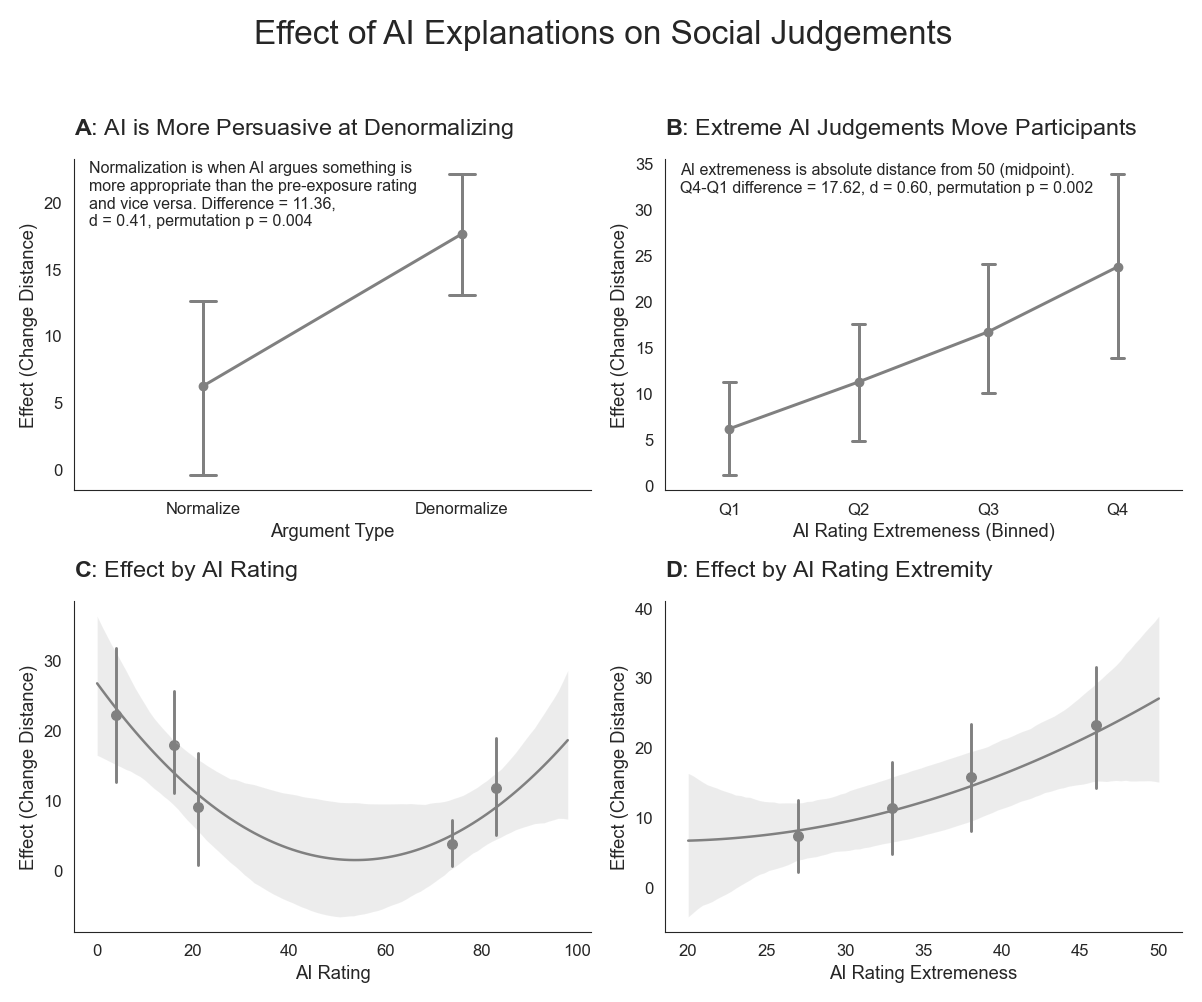

In [305]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import permutation_test

################################
# 1. Helper Functions
################################
def make_bold(text):
    """Formats a string to be bold in a matplotlib title."""
    return fr"$\bf{{{text}}}$"

def cohens_d(x, y):
    """Calculates Cohen's d for independent samples."""
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2: return 0
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std if pooled_std > 0 else 0

def statistic(x, y):
    """Calculates the difference in means."""
    return np.mean(x) - np.mean(y)

def bucket_label(x, num_buckets):
    """Creates quartile labels for a continuous variable."""
    return pd.qcut(x, q=num_buckets, labels=[f"Q{i+1}" for i in range(num_buckets)], duplicates='drop')

################################
# 2. Feature Engineering
################################
df['rating_extreme'] = abs(df['rating'] - 50)
df['rating_extreme_bin'] = bucket_label(df['rating_extreme'], 4)
df['convince_type'] = np.where(df['rating'] < df['pre'], "Denormalize", "Normalize")

################################
# 3. Statistical Analysis
################################

# --- Stats for Plot C ---
denorm = df[df['convince_type'] == 'Denormalize']['change_distance']
norm = df[df['convince_type'] == 'Normalize']['change_distance']
d_convince = cohens_d(denorm, norm)
res_convince = permutation_test((denorm, norm), statistic, n_resamples=10000, random_state=42)
stats_convince_str = f"Normalization is when AI argues something is\nmore appropriate than the pre-exposure rating\nand vice versa. Difference = {res_convince.statistic:.2f},\nd = {d_convince:.2f}, permutation p = {res_convince.pvalue:.3f}"

# --- Stats for Plot D ---
q1_extremity = df[df['rating_extreme_bin'] == 'Q1']['change_distance']
q4_extremity = df[df['rating_extreme_bin'] == 'Q4']['change_distance']
d_extremity = cohens_d(q4_extremity, q1_extremity)
res_extremity = permutation_test((q4_extremity, q1_extremity), statistic, n_resamples=10000, random_state=42)
stats_extremity_str = f"AI extremeness is absolute distance from 50 (midpoint).\nQ4-Q1 difference = {res_extremity.statistic:.2f}, d = {d_extremity:.2f}, permutation p = {res_extremity.pvalue:.3f}"

################################
# 4. Plotting
################################
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Effect of AI Explanations on Social Judgements", fontsize=24)

# Top-left
sns.pointplot(data=df, x='convince_type', y='change_distance', ax=axes[0, 0], color='gray', capsize=.1)
axes[0, 0].set_ylabel("Effect (Change Distance)")
axes[0, 0].set_xlabel("Argument Type")
axes[0, 0].set_title(f"{make_bold('A')}: AI is More Persuasive at Denormalizing")
axes[0, 0].text(0.03, 0.8, stats_convince_str, ha="left", transform=axes[0, 0].transAxes)

# Top-right
sns.pointplot(data=df, x='rating_extreme_bin', y='change_distance', ax=axes[0, 1], color='gray', capsize=.1)
axes[0, 1].set_ylabel("Effect (Change Distance)")
axes[0, 1].set_xlabel("AI Rating Extremeness (Binned)")
axes[0, 1].set_title(f"{make_bold('B')}: Extreme AI Judgements Move Participants")
axes[0, 1].text(0.03, 0.9, stats_extremity_str, ha="left", transform=axes[0, 1].transAxes)

# Bottom-left
sns.regplot(data=df, x='rating', y='change_distance', color='gray', order=2, x_bins=5, ax=axes[1, 0])
axes[1, 0].set_xlabel("AI Rating")
axes[1, 0].set_ylabel("Effect (Change Distance)")
axes[1, 0].set_title(f"{make_bold('C')}: Effect by AI Rating")

# Bottom-right
sns.regplot(data=df, y='change_distance', x='rating_extreme', color='gray', order=2, x_bins=4, ax=axes[1, 1])
axes[1, 1].set_xlabel("AI Rating Extremeness")
axes[1, 1].set_ylabel("Effect (Change Distance)")
axes[1, 1].set_title(f"{make_bold('D')}: Effect by AI Rating Extremity")

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("grid.pdf")